# GOAL
- Create a data set that is like entity affiliation dataset in the PitchBook data for hospitals and VCs only
- That has all the hospital and vc firms in one data set.
    - Some affiliation is missing in the PitchBook data so we will need to do some manual work to fill in the gaps.
- I want both pair in the same dataset
- I want to enumerate & assign id to all the unique pairs
- I want to sort the dataset by pair number or ID so every pair is next to each other
- I want to mark those that added to the dataset manually and those that were in the PitchBook data
- I want to fill in the missing affiliation information from PitchBook data
- At the end check exatcly two rows have the same pair ID, one for each direction of the affiliation
- I want to specify which one is hospital and which one is VC for each row

# CONFIG

In [2]:
import sys
import pandas as pd
from pathlib import Path

sys.modules.pop('a20_config.a10_config', None)  # force reload
from a20_config.a10_config import dyr, file, const, var, fi

Path.cwd()

PosixPath('/sharedata/camm/c_projects/i100_g7__VC_arms')

# PIPELINE

## Create initial combined dataset from two datasets, one is hospital with affiliated VCs, the other is VCs with affiliated hospitals.
- Also checking for duplicates after combining

In [35]:
# read hospitals data
df_00 = pd.read_excel(file.di_sp050_15__hospitals_with_affiliated_vc__manual_list_added_to_by_data_property__xl)

# add two columns showing the affiliate type is hospital and the entity type is VC
df_00[var.affiliate_type] = const.hospital
df_00[var.entity_type] = const.vc

df_00

,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type
0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc
1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc
2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc
3,56040-94,56084-95,MemorialCare Health System,Clinics/Outpatient Services,"Long Beach, CA",1907.0,Parent,Long Beach,California,United States,01/30/2023,hospital,vc
4,433943-74,185286-07,St. John Medical Center (Sisters of Charity He...,Hospitals/Inpatient Services,"Cleveland, OH",NaN,Sister,Cleveland,Ohio,United States,05/06/2023,hospital,vc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,435625-48,99685-00,Renal Services,Clinics/Outpatient Services,"London, United Kingdom",2007.0,Sister,London,England,United Kingdom,05/06/2023,hospital,vc
244,340845-76,127260-28,Cleveland Clinic,Acquirer,"Cleveland, OH",1921.0,Parent,Cleveland,Ohio,United States,01/30/2023,hospital,vc
245,482380-93,159211-27,Edward-Elmhurst Health,Hospitals/Inpatient Services,"Naperville, IL",2013.0,Parent,Naperville,Illinois,United States,05/06/2023,hospital,vc
246,435253-51,484448-50,Foundations for Change,Clinics/Outpatient Services,"Peoria, AZ",2017.0,Subsidiary,Peoria,Arizona,United States,01/30/2023,hospital,vc


In [36]:
# read VCs data
df_05 = pd.read_excel(file.di_sp050_20__VCs_with_affiliated_hospitals_manual_list_added_to_by_data_property__xl)

# specify the affiliate type is VC and entity type is hospital for this dataset
df_05[var.affiliate_type] = const.vc
df_05[var.entity_type] = const.hospital

df_05

,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type
0,151167-52,399434-32,Healthcare Innovation Fund,Corporate Venture Capital,"Lafayette, LA",NaN,Subsidiary,Lafayette,Louisiana,United States,05/06/2023,vc,hospital
1,433878-04,42282-37,PureTech Health,Venture Capital,"Boston, MA",2001.0,Parent,Boston,Massachusetts,United States,01/30/2023,vc,hospital
2,151100-02,55472-23,Health Insight Capital,Corporate Venture Capital,"Nashville, TN",NaN,Sister,Nashville,Tennessee,United States,01/30/2023,vc,hospital
3,433997-20,168311-71,Sodexo Ventures,Corporate Venture Capital,"Issy les Moulineaux, France",2016.0,Sister,Issy les Moulineaux,NaN,France,01/30/2023,vc,hospital
4,56084-95,56040-94,MemorialCare Innovation Fund,Corporate Venture Capital,"Long Beach, CA",1993.0,Subsidiary,Long Beach,California,United States,01/30/2023,vc,hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,10466-20,168311-71,Sodexo Ventures,Corporate Venture Capital,"Issy les Moulineaux, France",2016.0,Sister,Issy les Moulineaux,NaN,France,01/30/2023,vc,hospital
247,10326-34,167357-98,Well Ventures,Corporate Venture Capital,"Deerfield, IL",2009.0,Subsidiary,Deerfield,Illinois,United States,01/30/2023,vc,hospital
248,10308-70,120443-77,McKesson Ventures,Corporate Venture Capital,"San Francisco, CA",2014.0,Sister,San Francisco,California,United States,01/30/2023,vc,hospital
249,152034-13,166204-27,Fresenius Medical Care Ventures,Corporate Venture Capital,"Bad Homburg, Germany",2016.0,Sister,Bad Homburg,NaN,Germany,01/30/2023,vc,hospital


In [37]:
# concatenate the two datasets, keep all rows, and reset the index
df_all_pb = pd.concat([df_00, df_05], ignore_index = True)

print(df_all_pb.shape)
df_all_pb

(499, 13)


,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type
0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc
1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc
2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc
3,56040-94,56084-95,MemorialCare Health System,Clinics/Outpatient Services,"Long Beach, CA",1907.0,Parent,Long Beach,California,United States,01/30/2023,hospital,vc
4,433943-74,185286-07,St. John Medical Center (Sisters of Charity He...,Hospitals/Inpatient Services,"Cleveland, OH",NaN,Sister,Cleveland,Ohio,United States,05/06/2023,hospital,vc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,10466-20,168311-71,Sodexo Ventures,Corporate Venture Capital,"Issy les Moulineaux, France",2016.0,Sister,Issy les Moulineaux,NaN,France,01/30/2023,vc,hospital
495,10326-34,167357-98,Well Ventures,Corporate Venture Capital,"Deerfield, IL",2009.0,Subsidiary,Deerfield,Illinois,United States,01/30/2023,vc,hospital
496,10308-70,120443-77,McKesson Ventures,Corporate Venture Capital,"San Francisco, CA",2014.0,Sister,San Francisco,California,United States,01/30/2023,vc,hospital
497,152034-13,166204-27,Fresenius Medical Care Ventures,Corporate Venture Capital,"Bad Homburg, Germany",2016.0,Sister,Bad Homburg,NaN,Germany,01/30/2023,vc,hospital


In [38]:
# drop duplicates if there are any, and check the shape again to see if there are duplicates
df_all_pb = df_all_pb.drop_duplicates()

print(df_all_pb.shape)
df_all_pb

(499, 13)


,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type
0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc
1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc
2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc
3,56040-94,56084-95,MemorialCare Health System,Clinics/Outpatient Services,"Long Beach, CA",1907.0,Parent,Long Beach,California,United States,01/30/2023,hospital,vc
4,433943-74,185286-07,St. John Medical Center (Sisters of Charity He...,Hospitals/Inpatient Services,"Cleveland, OH",NaN,Sister,Cleveland,Ohio,United States,05/06/2023,hospital,vc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,10466-20,168311-71,Sodexo Ventures,Corporate Venture Capital,"Issy les Moulineaux, France",2016.0,Sister,Issy les Moulineaux,NaN,France,01/30/2023,vc,hospital
495,10326-34,167357-98,Well Ventures,Corporate Venture Capital,"Deerfield, IL",2009.0,Subsidiary,Deerfield,Illinois,United States,01/30/2023,vc,hospital
496,10308-70,120443-77,McKesson Ventures,Corporate Venture Capital,"San Francisco, CA",2014.0,Sister,San Francisco,California,United States,01/30/2023,vc,hospital
497,152034-13,166204-27,Fresenius Medical Care Ventures,Corporate Venture Capital,"Bad Homburg, Germany",2016.0,Sister,Bad Homburg,NaN,Germany,01/30/2023,vc,hospital


In [39]:
# result: there is no duplicates because number of rows remained the same

In [40]:
# mark all rows as from PitchBook data, later we will mark the manually added ones af False in this column
# there are some items that their pair counterpart is missing in the PitchBook data, we will add those pairs later, and mark them as not from PitchBook data

df_10 = df_all_pb.copy()

df_10[var.from_pitchbook] = True

##  Generate pair IDs

In [41]:
# generate pair IDs for each unique pair (regardless of order), and ensure both directions of the pair are present in the dataset.

df_15 = df_10.copy()

# Create a set of existing pairs with normalized order (smaller, larger)
pair_to_id = {}
pair_id_counter = 0

# First pass: assign IDs to existing pairs
for idx, row in df_15.iterrows():
    val1, val2 = row[var.entity_id], row[var.affiliate_id]
    # Normalize pair to always have consistent ordering for ID assignment
    normalized_pair = tuple(sorted([val1, val2]))

    if normalized_pair not in pair_to_id:
        pair_to_id[normalized_pair] = pair_id_counter
        pair_id_counter += 1

# Add pair_id column to original DataFrame
df_15[var.pair_id] = df_15.apply(lambda row: pair_to_id[tuple(sorted([row[var.entity_id], row[var.affiliate_id]]))],
                                 axis = 1)

# Move pair_id to first position, keep all other columns
cols = [var.pair_id] + [col for col in df_15.columns if col != var.pair_id]
df_15 = df_15[cols]

df_15 = df_15.sort_values(by = var.pair_id).reset_index(drop = True)

df_15

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc,True
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital,True
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital,True
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc,True
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,249,164588-68,507452-14,Wanyuandia Investment,Corporate Venture Capital,"Hangzhou, China",2021.0,Subsidiary,Hangzhou,Zhejiang,China,01/30/2023,vc,hospital,True
495,250,114336-37,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,United States,05/12/2023,vc,hospital,True
496,251,64863-82,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Subsidiary,Marietta,Georgia,United States,05/12/2023,vc,hospital,True
497,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital,True


## FIND MISSING ROWS FOR PAIRS

In [42]:
# Find missing reversed pairs

existing_pairs = set(zip(df_15[var.entity_id], df_15[var.affiliate_id]))
missing_pairs = []

for val1, val2 in existing_pairs:
    if (val2, val1) not in existing_pairs:
        normalized_pair = tuple(sorted([val1, val2]))
        missing_pairs.append({
                var.entity_id   : val2,
                var.affiliate_id: val1,
                var.pair_id     : pair_to_id[normalized_pair]
        })

# Combine original and missing pairs
if missing_pairs:
    missing_df = pd.DataFrame(missing_pairs)
    df_20_complete = pd.concat([df_15, missing_df], ignore_index = True)
else:
    df_20_complete = df_15.copy()

# Sort by pair_id for better visualization
df_20_complete = df_20_complete.sort_values('pair_id').reset_index(drop = True)

# number of missing pairs added
len(missing_pairs)

9

In [43]:
# Are all pair IDs appearing exactly twice? There shouldn't be any missing item in any pair because we have added the missing pairs in the previous step

# Check the count of each pair_id
pair_counts = df_20_complete[var.pair_id].value_counts().sort_index()

print("Count of each pair_id:", pair_counts)

# Check if all pair_ids appear exactly twice
all_twice = (pair_counts == 2).all()

if all_twice:
    print("\n✓ All pair_ids appear exactly twice!")
else:
    print("\n✗ Some pair_ids do NOT appear exactly twice:")
    print(pair_counts[pair_counts != 2])

Count of each pair_id: pair_id
0      2
1      2
2      2
3      2
4      2
      ..
249    2
250    2
251    2
252    2
253    2
Name: count, Length: 254, dtype: int64

✓ All pair_ids appear exactly twice!


In [70]:
_fp = file.di_sp060_01__all_hospitals_and_VC_affiliations__preliminary__xl

In [71]:
# save intermediate result
df_20_complete.to_excel(_fp, index = False)

## FILL IN MISSING AFFILIATION INFORMATION FROM PITCHBOOK DATA, FOR ADDED ROWS

In [174]:
# Fill in missing affiliation information from PitchBook data
df_30_complete = pd.read_excel(_fp)

# Solution 1: Convert to boolean explicitly (RECOMMENDED)
df_30_complete[var.from_pitchbook] = df_30_complete[var.from_pitchbook].fillna(False).astype(bool)
df_30_complete

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc,True
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital,True
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital,True
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc,True
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
504,252,62848-00,111991-60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
505,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital,True
506,253,157276-27,166341-79,Oravision Ventures,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,United States,01/30/2023,vc,hospital,True


In [175]:
# how many rows added (i.e. that were missing in the PitchBook data and need to be filled manually?)

msk = df_30_complete[var.from_pitchbook].eq(False)

df_manual = df_30_complete[msk]
print(len(df_manual))
df_manual

9


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
21,10,266429-44,55440-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
343,171,361472-59,399434-32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
455,227,513338-32,11259-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
497,248,158931-46,125942-95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
498,249,507452-14,164588-68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
500,250,527371-30,114336-37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
504,252,62848-00,111991-60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
507,253,166341-79,157276-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [176]:
df_40_ref = df_all_pb.copy()

In [177]:
df_40_ref = df_40_ref.drop(columns = [var.entity_id])

In [178]:
df_40_ref = df_40_ref.drop_duplicates(subset = [var.affiliate_id])
print(df_40_ref.shape)

(335, 12)


In [179]:
df_40_ref = df_40_ref.drop_duplicates()
print(df_40_ref.shape)

(335, 12)


In [180]:
# make sure all the affiliate ids are unique
key_counts = df_40_ref[var.affiliate_id].value_counts()
duplicates = key_counts[key_counts > 1]
duplicates

Series([], Name: count, dtype: int64)

In [181]:
# so no duplicates, I can be sure there is one and only one row per affiliate_id
assert duplicates.empty, f"Reference DataFrame has duplicate keys: {duplicates.index.tolist()}"

In [182]:
# Assert all keys in df exist in ref_df

missing_keys = set(df_30_complete[var.affiliate_id]) - set(df_40_ref[var.affiliate_id])
found_keys = set(df_40_ref[var.affiliate_id]) & set(df_manual[var.affiliate_id])

print(f"Keys in df not found in reference: {missing_keys}", "- number of missing keys:", len(missing_keys))
print(f'number of total unique affiliate ids in added rows: {len(set(df_manual[var.affiliate_id]))}')
print(f'number of found keys: {len(found_keys)}')

Keys in df not found in reference: {'164588-68', '114336-37', '11259-10', '64863-82'} - number of missing keys: 4
number of total unique affiliate ids in added rows: 9
number of found keys: 5


In [183]:
# so there are 4 missing keys, i.e. there are 4 affiliate ids in the target df that are not in the reference df, which means we won't be able to fill in the affiliation information for those 4 rows using the reference df, and we will need to fill in those 4 rows manually.
# it also means we had these 4 rows only as entity Ids, we never had them in the affiliated Id column.

In [184]:
# fill in missing affiliation information from reference DataFrame, 5 out of 9 rows with missing affiliation will be filled in, and the remaining 4 rows will would still have nan information

# because all the keys in the ref df (the ids in the affiliate_id column) are unique, we can merge on the affiliate_id column to fill in the missing information, and we won't have any duplicates after the merge, we won't have any new rows after the merge
df_45_merged = df_30_complete.merge(df_40_ref, on = var.affiliate_id, how = 'left', suffixes = ('', '_ref'),
                                    validate = 'many_to_one')

# Just make sure no new rows are added after the merge

assert len(df_45_merged) == len(df_30_complete), "Merge introduced new rows, check the merge keys and method."

df_45_merged

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Industry_ref,Location_ref,YearFounded_ref,AffiliateType_ref,HQCity_ref,HQState_Province_ref,HQCountry_ref,LastUpdated_ref,affiliate_type_ref,entity_type_ref
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,...,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,...,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,...,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,...,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,...,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
504,252,62848-00,111991-60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc
505,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,...,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital
506,253,157276-27,166341-79,Oravision Ventures,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,...,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,United States,01/30/2023,vc,hospital


In [185]:
# check on those 4 keys, they should have all nan values in the columns from the reference df after the merge
msk = df_45_merged[var.affiliate_id].isin(missing_keys)
df_45_merged[msk]

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Industry_ref,Location_ref,YearFounded_ref,AffiliateType_ref,HQCity_ref,HQState_Province_ref,HQCountry_ref,LastUpdated_ref,affiliate_type_ref,entity_type_ref
455,227,513338-32,11259-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
498,249,507452-14,164588-68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500,250,527371-30,114336-37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [186]:
# -> yes they still have nan values in the columns from the reference df, because they weren't found in the ref df

In [187]:
# now check on the 5 out of 9 missing rows that should have affiliation data in the ref df.
msk = df_45_merged[var.affiliate_id].isin(found_keys)

df_47 = df_45_merged[msk]

print(df_47.shape)
print(df_47[var.affiliate_id].nunique())
df_47

(13, 26)
5


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,...,Industry_ref,Location_ref,YearFounded_ref,AffiliateType_ref,HQCity_ref,HQState_Province_ref,HQCountry_ref,LastUpdated_ref,affiliate_type_ref,entity_type_ref
21,10,266429-44,55440-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,United States,01/30/2023,vc,hospital
23,11,62517-16,55440-55,Highmark Health Ventures,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,...,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,United States,01/30/2023,vc,hospital
69,34,52247-80,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc
228,114,454651-48,125942-95,Medsi Group,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,...,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,Russia,05/06/2023,hospital,vc
292,146,166728-88,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,...,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc
341,170,151167-52,399434-32,Healthcare Innovation Fund,Corporate Venture Capital,"Lafayette, LA",NaN,Subsidiary,Lafayette,Louisiana,...,Corporate Venture Capital,"Lafayette, LA",NaN,Subsidiary,Lafayette,Louisiana,United States,05/06/2023,vc,hospital
343,171,361472-59,399434-32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Corporate Venture Capital,"Lafayette, LA",NaN,Subsidiary,Lafayette,Louisiana,United States,05/06/2023,vc,hospital
399,199,158930-74,125942-95,Medsi Group,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,...,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,Russia,05/06/2023,hospital,vc
401,200,158931-19,125942-95,Medsi Group,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,...,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,Russia,05/06/2023,hospital,vc
404,202,62120-17,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,...,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,United States,01/30/2023,hospital,vc


In [188]:
# -> yes the columns with _ref suffix have not nan values for these rows

In [189]:
# Fill in the columns (update existing or add new)
# Now I want to fill the original columns from _ref columns

df_50_complete = df_30_complete.copy()

for col in df_40_ref.columns:
    if col != var.affiliate_id:  # Skip the key column
        if col in df_50_complete.columns:
            # Update existing column
            # we don't lose existing data because they are repeated exactly in the merged df
            # if the column is the df_merged column replace it with the original column, otherwise keep the original column (make no change)
            if f'{col}_ref' in df_45_merged.columns:
                df_50_complete[col] = df_45_merged[f'{col}_ref']
        else:
            # Add new column
            df_50_complete[col] = df_45_merged[col]

# the number of rows must have remained the same
assert len(df_50_complete) == len(df_30_complete), "Filling process changed the number of rows, check the logic."
print(df_50_complete.shape)

(508, 15)


In [190]:
# There are still 4 rows with NaN in some columns but 5 columns are filled
msk = df_50_complete[var.from_pitchbook].eq(False)
df_manual_filled = df_50_complete[msk]
print(df_manual_filled.shape)
df_manual_filled

(9, 15)


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
21,10,266429-44,55440-55,Highmark Health Ventures,Venture Capital,"Pittsburgh, PA",1990.0,Sister,Pittsburgh,Pennsylvania,United States,01/30/2023,vc,hospital,False
343,171,361472-59,399434-32,Healthcare Innovation Fund,Corporate Venture Capital,"Lafayette, LA",NaN,Subsidiary,Lafayette,Louisiana,United States,05/06/2023,vc,hospital,False
455,227,513338-32,11259-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
497,248,158931-46,125942-95,Medsi Group,Clinics/Outpatient Services,"Moscow, Russia",1996.0,Sister,Moscow,NaN,Russia,05/06/2023,hospital,vc,False
498,249,507452-14,164588-68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
500,250,527371-30,114336-37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
504,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc,False
507,253,166341-79,157276-27,Ora Clinical,Other Healthcare Services,"Andover, MA",1985.0,Parent,Andover,Massachusetts,United States,01/30/2023,hospital,vc,False


In [191]:
# for those 4 rows I still can fill in the affiliation type from its pair,
# if the pair is sister the affiliation type should be the same i.e. sister
# if the pair is parent-subsidiary the affiliation type should be reversed

df_55_complete = df_50_complete.copy()
df = df_55_complete

# Define the reverse affiliation mapping
reverse_affiliation = {
        const.par: const.sub,
        const.sub: const.par,
        const.sis: const.sis,
}

msk = df[var.aff_type].isna()

# Fill missing affiliations based on reverse pairs
for idx, row in df[msk].iterrows():

    # Find the reverse pair (same pair_id, but col1 and col2 swapped)
    reverse_mask = (
            (df[var.pair_id] == row[var.pair_id]) &
            (df[var.entity_id] == row[var.affiliate_id]) &
            (df[var.affiliate_id] == row[var.entity_id])
    )

    reverse_row = df[reverse_mask]

    assert len(reverse_row) == 1

    reverse_affiliation_value = reverse_row.iloc[0][var.aff_type]
    reverse_affiliated_type_value = reverse_row.iloc[0][var.affiliate_type]

    if pd.notna(reverse_affiliation_value):
        # Apply the reverse mapping
        df.at[idx, var.aff_type] = reverse_affiliation[reverse_affiliation_value]
        df.at[idx, var.affiliate_type] = const.hospital if reverse_affiliated_type_value == const.vc else const.vc
        df.at[idx, var.entity_type] = const.hospital if reverse_affiliated_type_value == const.hospital else const.vc

df_55_complete[msk]

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
455,227,513338-32,11259-10,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,vc,hospital,False
498,249,507452-14,164588-68,NaN,NaN,NaN,NaN,Parent,NaN,NaN,NaN,NaN,hospital,vc,False
500,250,527371-30,114336-37,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False


In [192]:
# manually check if those rows now have the right affiliation type

# find where we didn't have the affiliation type before, and check if they are filled in now
msk = df_50_complete[var.aff_type].isna()
df_a = df_50_complete[msk]

# check the same rows in the new df, they should have the affiliation type filled in now
msk = df_55_complete[var.pair_id].isin(df_a[var.pair_id])
df_b = df_55_complete[msk]
df_b

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
454,227,11259-10,513338-32,Novartis (Ophthalmology and Respiratory Units),Clinics/Outpatient Services,"Basel, Switzerland",NaN,Sister,Basel,NaN,Switzerland,01/30/2023,hospital,vc,True
455,227,513338-32,11259-10,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,vc,hospital,False
498,249,507452-14,164588-68,NaN,NaN,NaN,NaN,Parent,NaN,NaN,NaN,NaN,hospital,vc,False
499,249,164588-68,507452-14,Wanyuandia Investment,Corporate Venture Capital,"Hangzhou, China",2021.0,Subsidiary,Hangzhou,Zhejiang,China,01/30/2023,vc,hospital,True
500,250,527371-30,114336-37,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False
501,250,114336-37,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,United States,05/12/2023,vc,hospital,True
502,251,64863-82,527371-30,Catalyst by Wellstar,Corporate Venture Capital,"Marietta, GA",2021.0,Sister,Marietta,Georgia,United States,05/12/2023,vc,hospital,True
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False


In [193]:
# -> YES they are filled correctly, I checked it manually

In [194]:
df_55_complete = df_55_complete.sort_values(by = var.pair_id).reset_index(drop = True)
df_55_complete

,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc,True
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital,True
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital,True
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc,True
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False
504,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc,False
505,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital,True
506,253,157276-27,166341-79,Oravision Ventures,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,United States,01/30/2023,vc,hospital,True


In [210]:
# save until this step result dataframe
_f = file.di_sp060_03__xl
print(_f)

/sharedata/camm/c_projects/i100_g7__VC_arms/f10_data_interim/di_sp060_03.xlsx


In [211]:
df_55_complete.to_excel(_f, index = False)

In [212]:
df_55_complete = pd.read_excel(_f)

## AFFILIATION TYPE CHECKS

In [213]:
# find any other pair that the relation is (sister, parent) or (sister, subsidiary) or vice versa, which is not valid, and mark them as not valid affiliation type

def _check_pair_par_sis(gp):
    vals = gp[var.aff_type]
    return vals.iloc[0] == const.par and vals.iloc[1] == const.sis


df56 = df_55_complete.groupby(var.pair_id).filter(_check_pair_par_sis)
print("number of parent, sister rows we had:", len(df56) / 2)

_pair_ids_2_drop = set(df56[var.pair_id])


def _check_sis_par(gp):
    vals = gp[var.aff_type]
    return vals.iloc[0] == const.sis and vals.iloc[1] == const.par


df57 = df_55_complete.groupby(var.pair_id).filter(_check_sis_par)
print("number of sister, parent rows we had:", len(df57) / 2)

_pair_ids_2_drop = _pair_ids_2_drop.union(set(df57[var.pair_id]))


def _check_sis_sub(gp):
    vals = gp[var.aff_type]
    return vals.iloc[0] == const.sis and vals.iloc[1] == const.sub


df58 = df_55_complete.groupby(var.pair_id).filter(_check_sis_sub)
print("number of sister, subsidiary rows we had:", len(df58) / 2)

_pair_ids_2_drop = _pair_ids_2_drop.union(set(df58[var.pair_id]))


def _check_sub_sis(gp):
    vals = gp[var.aff_type]
    return vals.iloc[0] == const.sub and vals.iloc[1] == const.sis


df59 = df_55_complete.groupby(var.pair_id).filter(_check_sub_sis)
print("number of subsidiary, sister rows we had:", len(df59) / 2)

_pair_ids_2_drop = _pair_ids_2_drop.union(set(df59[var.pair_id]))

print("number of all pair ids to drop:", len(_pair_ids_2_drop))

# mark those pair ids as not valid affiliation type in the original df
df_55_complete.loc[df_55_complete[var.pair_id].isin(_pair_ids_2_drop), var.not_valid_affiliation_type] = True


number of parent, sister rows we had: 12.0
number of sister, parent rows we had: 6.0
number of sister, subsidiary rows we had: 5.0
number of subsidiary, sister rows we had: 4.0
number of all pair ids to drop: 27



✓ Table saved to: /sharedata/camm/c_projects/i100_g7__VC_arms/g20_results_tables/sp060_20.svg


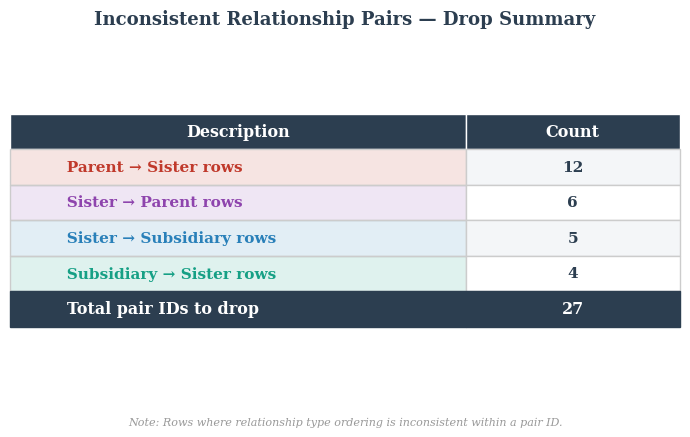

In [3]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

# --- Data ---
rows = [
        ('Parent → Sister rows', 12),
        ('Sister → Parent rows', 6),
        ('Sister → Subsidiary rows', 5),
        ('Subsidiary → Sister rows', 4),
]
total = 27

cell_data = [[desc, f"{count:,.0f}"] for desc, count in rows]
cell_data.append(['Total pair IDs to drop', f"{total:,}"])

col_labels = ['Description', 'Count']

# --- Colors ---
header_color = '#2C3E50'
row_colors = ['#FFFFFF', '#F4F6F8']
row_text_colors = ['#C0392B', '#8E44AD', '#2980B9', '#16A085']  # one per data row

fig, ax = plt.subplots(figsize = (7, len(cell_data) * 0.55 + 1.6))
ax.axis('off')

table = ax.table(
        cellText = cell_data,
        colLabels = col_labels,
        cellLoc = 'center',
        colWidths = [0.68, 0.32],
        loc = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# --- Header ---
for j in range(2):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(weight = 'bold', color = 'white', fontsize = 11.5)
    cell.set_edgecolor('white')

# --- Data rows ---
for i in range(1, len(cell_data) + 1):
    is_total = (i == len(cell_data))
    for j in range(2):
        cell = table[(i, j)]
        cell.set_edgecolor('#CCCCCC')
        if is_total:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(weight = 'bold', color = 'white', fontsize = 11.5)
            cell.set_edgecolor('#2C3E50')
        else:
            bg = row_colors[i % 2]
            cell.set_facecolor(bg)
            if j == 0:
                # tint + colored text per row
                cell.set_facecolor(row_text_colors[i - 1] + '22')
                cell.set_text_props(color = row_text_colors[i - 1],
                                    weight = 'bold', fontsize = 11)
            else:
                cell.set_text_props(color = '#2C3E50', weight = 'bold')

# Left-align description column
for i in range(1, len(cell_data) + 1):
    table[(i, 0)].set_text_props(ha = 'left')
    table[(i, 0)].get_text().set_text('  ' + cell_data[i - 1][0])

# --- Title & note ---
fig.text(0.5, 0.97, 'Inconsistent Relationship Pairs — Drop Summary',
         ha = 'center', va = 'top',
         fontsize = 13, fontweight = 'bold', color = '#2C3E50', fontfamily = 'serif')
fig.text(0.5, 0.01,
         'Note: Rows where relationship type ordering is inconsistent within a pair ID.',
         ha = 'center', va = 'bottom',
         fontsize = 8, color = '#999999', style = 'italic', fontfamily = 'serif')

plt.tight_layout(rect = [0, 0.04, 1, 0.93])

output_path = fi.sp060_20  # update as needed
plt.savefig(output_path, format = 'svg', bbox_inches = 'tight', dpi = 300)
print(f"\n✓ Table saved to: {output_path}")

plt.show()

In [216]:
# make sure that all the pairs have (sister, sister) affiliation type or (parent, subsidiary) or (subsidiary, parent), no other combination is allowed
def _check_valid_affiliation(gp):
    vals = gp[var.aff_type]
    return (vals.iloc[0] == const.sis and vals.iloc[1] == const.sis) or \
        (vals.iloc[0] == const.par and vals.iloc[1] == const.sub) or \
        (vals.iloc[0] == const.sub and vals.iloc[1] == const.par)


df_invalid = df_55_complete.groupby(var.pair_id).filter(lambda gp: not _check_valid_affiliation(gp))
df_invalid = df_invalid[df_invalid[var.not_valid_affiliation_type].ne(True)]

print("number of invalid pairs we have:", len(df_invalid) / 2)

number of invalid pairs we have: 0.0


In [226]:
# so there is no invalid pair that we haven't marked as not valid affiliation type, which means all the invalid pairs are marked correctly
_fp = file.di_sp060_05__all_hospitals_and_VC_affiliations__xl

In [231]:
df_55_complete.to_excel(_fp, index = False)
print(len(df_55_complete))

508


In [232]:
df60 = pd.read_excel(_fp)

In [233]:
msk = df60[var.not_valid_affiliation_type].eq(True)
df60 = df60[~msk]

print(len(df60))
df60

454


,pair_id,EntityID,AffiliateID,AffiliateName,Industry,Location,YearFounded,AffiliateType,HQCity,HQState_Province,HQCountry,LastUpdated,affiliate_type,entity_type,FromPitchBook,not_valid_affiliation_type
0,0,434783-53,166514-86,Ballad Health,Hospitals/Inpatient Services,"Johnson City, TN",NaN,Parent,Johnson City,Tennessee,United States,05/06/2023,hospital,vc,True,NaN
1,0,166514-86,434783-53,Ballad Ventures,Corporate Venture Capital,"Johnson City, TN",2020.0,Subsidiary,Johnson City,Tennessee,United States,01/30/2023,vc,hospital,True,NaN
2,1,62802-10,57221-29,Bank Austria TFV,Venture Capital,"Vienna, Austria",1996.0,Sister,Vienna,NaN,Austria,01/30/2023,vc,hospital,True,NaN
3,1,57221-29,62802-10,Clinique Saint,Hospitals/Inpatient Services,"Poissy, France",1959.0,Sister,Poissy,NaN,France,03/02/2023,hospital,vc,True,NaN
4,2,433943-74,55165-33,University Hospitals,Acquirer,NaN,1866.0,Parent,NaN,NaN,NaN,05/06/2023,hospital,vc,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,251,527371-30,64863-82,NaN,NaN,NaN,NaN,Sister,NaN,NaN,NaN,NaN,hospital,vc,False,NaN
504,252,62848-00,111991-60,Netdoktor.at,Other Healthcare Services,"Vienna, Austria",2001.0,Sister,Vienna,NaN,Austria,01/30/2023,hospital,vc,False,NaN
505,252,111991-60,62848-00,DLD Ventures,Corporate Venture Capital,"Munich, Germany",2007.0,Sister,Munich,NaN,Germany,01/30/2023,vc,hospital,True,NaN
506,253,157276-27,166341-79,Oravision Ventures,Corporate Venture Capital,"Andover, MA",NaN,Subsidiary,Andover,Massachusetts,United States,01/30/2023,vc,hospital,True,NaN


## COUNT NUMBER OF VCs HOSPITALS AND PAIRS

In [275]:
# unique VCs
df = df60.copy()

msk = df[var.affiliate_type].eq(const.vc)
_n = df[msk][var.affiliate_id].nunique()

_d = {
        'total_rows': {'count': len(df)},
        'unique_vcs': {'count': _n},
}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}}


In [276]:
# unique hospitals
msk = df[var.affiliate_type].eq(const.hospital)
_n = df[msk][var.affiliate_id].nunique()

_d['unique_hospitals'] = {'count': _n}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}, 'unique_hospitals': {'count': 203}}


In [277]:
# how many unique sister hospital-VC pairs are there?
msk0 = df[var.aff_type].eq(const.sis)
df_sis = df[msk0]
_n = df_sis[var.pair_id].nunique()

_d['unique_sis_pairs'] = {'count': _n}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}, 'unique_hospitals': {'count': 203}, 'unique_sis_pairs': {'count': 189}}


In [278]:
# how many unique parent-sub pair we have?
msk = df[var.aff_type].isin([const.par, const.sub])
df_par_sub = df[msk]
_n = df_par_sub[var.pair_id].nunique()

_d['unique_par_sub_pairs'] = {'count': _n}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}, 'unique_hospitals': {'count': 203}, 'unique_sis_pairs': {'count': 189}, 'unique_par_sub_pairs': {'count': 38}}


In [279]:
# are there any other type of pairs we have?
print(len(df))
print(len(df_sis) + len(df_par_sub))
assert len(df_sis) + len(df_par_sub) == len(df)

454
454


In [280]:
# parent hospital and VC sub
msk1 = df[var.affiliate_type].eq(const.hospital) & df[var.aff_type].eq(const.par)
df_1 = df[msk1]
_n = len(df[msk1])

_d['parent_hospital_vc_subsidiary'] = {'count': _n}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}, 'unique_hospitals': {'count': 203}, 'unique_sis_pairs': {'count': 189}, 'unique_par_sub_pairs': {'count': 38}, 'parent_hospital_vc_subsidiary': {'count': 31}}


In [281]:
# how many parent VC and hospital as subsidiary we have?
msk2 = df[var.affiliate_type].eq(const.vc) & df[var.aff_type].eq(const.par)
df_2 = df[msk2]
_n = len(df[msk2])

_d['parent_vc_hospital_subsidiary'] = {'count': _n}
print(_d)

{'total_rows': {'count': 454}, 'unique_vcs': {'count': 110}, 'unique_hospitals': {'count': 203}, 'unique_sis_pairs': {'count': 189}, 'unique_par_sub_pairs': {'count': 38}, 'parent_hospital_vc_subsidiary': {'count': 31}, 'parent_vc_hospital_subsidiary': {'count': 7}}


In [282]:
df60.to_excel(file.dp_sp060_10__all_hospitals_and_VC_affiliations__final__xl, index = False)

In [283]:
_df = pd.DataFrame(_d)
_df

,total_rows,unique_vcs,unique_hospitals,unique_sis_pairs,unique_par_sub_pairs,parent_hospital_vc_subsidiary,parent_vc_hospital_subsidiary
count,454,110,203,189,38,31,7


In [287]:
_f = file.rt_sp060_15
_df.to_excel(_f, index = True)
print(_f)

/sharedata/camm/c_projects/i100_g7__VC_arms/g20_results_tables/rt_sp060_15__unique_vc_hospital_and_pair_types_count.xlsx
